# Create design matrix
- Map response as a regressor
- Then split it up based on valence and volatility
- See how they are correlated amongst each other

In [1]:
import utils

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import math
import os
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix, plot_design_matrix_correlation

plt.rcParams.update(plt.rcParamsDefault)
#pd.set_option('display.max_rows', None)

In [2]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','design_matrices')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# To load the trigger files
def find_trigger_file(pattern: str, folder: str = '.') -> pd.DataFrame:
    folder = Path(folder)
    matches = list(folder.glob(pattern))

    if len(matches) == 0:
        raise FileNotFoundError(f"No files matching '{pattern}' in {folder}")
    if len(matches) > 1:
        raise ValueError(f"Multiple files match '{pattern}': {matches}")

    return pd.read_csv(matches[0], delimiter=';')

In [4]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/'
unique_subject_ids = [52, 53, 54, 55, 57]
unique_sessions = [2, 3, 4]

# Now create a boxcar for every single trial
boxcar_duration = 1.7

# Load and combine the datasets
combined_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions)

print(combined_dataframe)

sub-054 did not complete session-04
sub-055 did not complete session-04
sub-057 did not complete session-03
sub-057 did not complete session-04
     subject_id     session  previous_outcome subjectively_correct  stay
0       sub-052  session-02              <NA>                 Late  <NA>
1       sub-052  session-02              <NA>                False  <NA>
2       sub-052  session-02              <NA>                 True  <NA>
3       sub-052  session-02              <NA>                 True  <NA>
4       sub-052  session-02              <NA>                False     1
...         ...         ...               ...                  ...   ...
4967    sub-057  session-02              <NA>                False  <NA>
4968    sub-057  session-02              <NA>                False     1
4969    sub-057  session-02              <NA>                 True     1
4970    sub-057  session-02              <NA>                 True  <NA>
4971    sub-057  session-02              <NA>        

Creating event file for subject 52 and session 2
Creating event file for subject 52 and session 2
              trial_type        onset  duration
0                  happy    38.511245       1.7
1                    cue    38.511245       1.7
2               response    38.993138       0.2
3            incongruent    38.511245       1.7
4               volatile    38.511245       1.7
...                  ...          ...       ...
2647                 cue  2001.304279       1.7
2648            response  2002.037879       0.2
2649         incongruent  2001.304279       1.7
2650              stable  2001.304279       1.7
2651  incongruent-stable  2001.304279       1.7

[2652 rows x 3 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:83: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:93: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


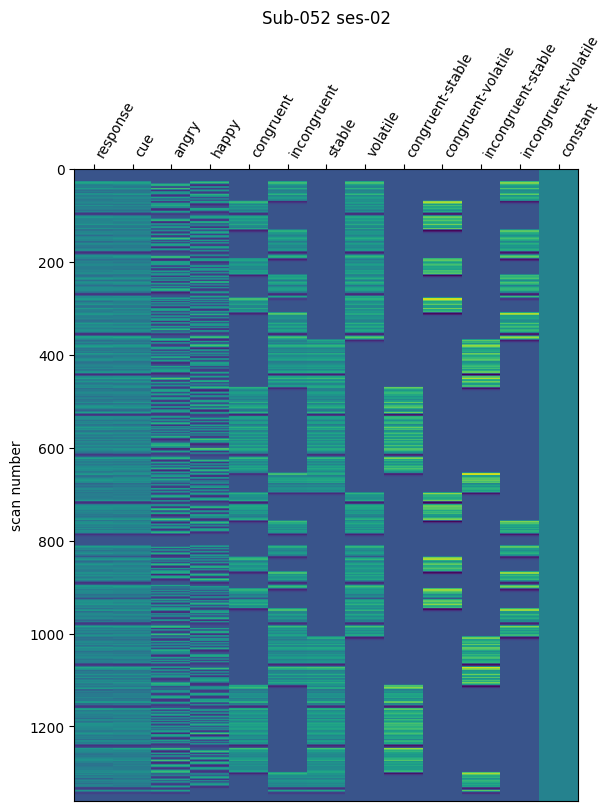

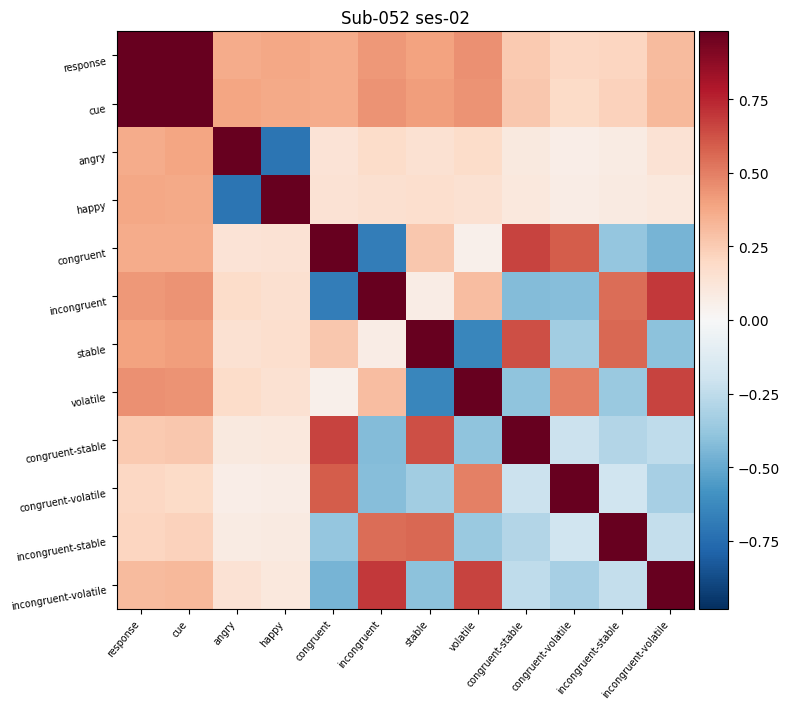

Creating event file for subject 52 and session 3
Creating event file for subject 52 and session 3
                trial_type        onset  duration
0                    angry    38.420506       1.7
1                      cue    38.420506       1.7
2                 response    38.929676       0.2
3              incongruent    38.420506       1.7
4                 volatile    38.420506       1.7
...                    ...          ...       ...
2575                   cue  2001.207662       1.7
2576              response  2001.944453       0.2
2577           incongruent  2001.207662       1.7
2578              volatile  2001.207662       1.7
2579  incongruent-volatile  2001.207662       1.7

[2580 rows x 3 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:83: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:93: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


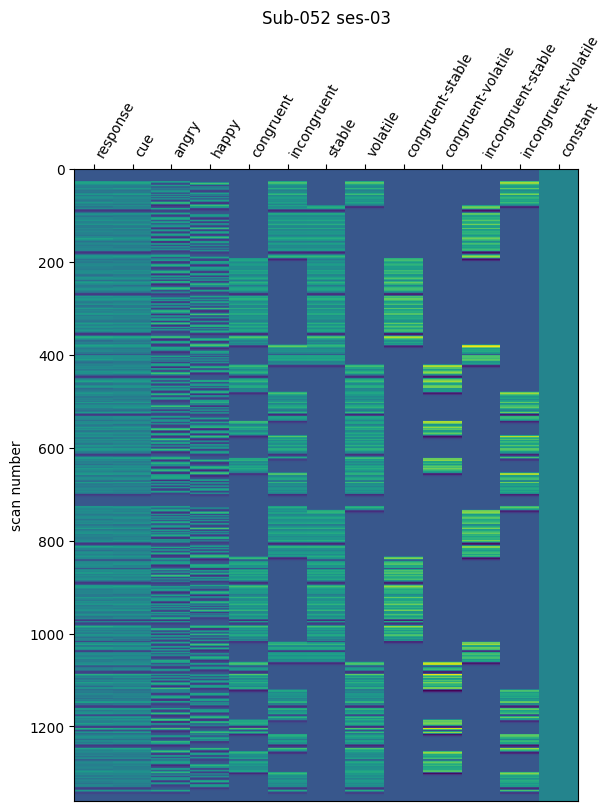

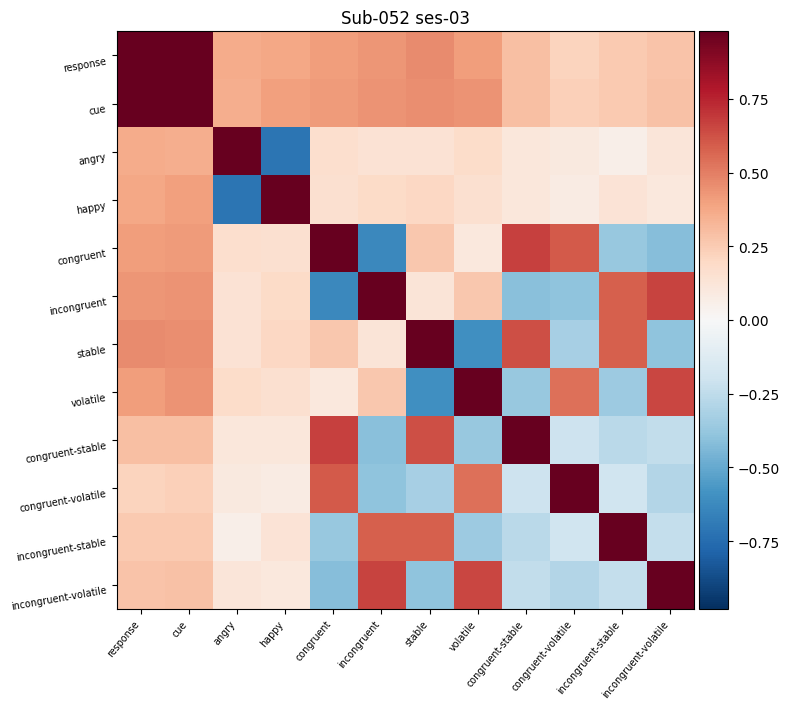

Creating event file for subject 52 and session 4
Creating event file for subject 52 and session 4
            trial_type        onset  duration
0                angry    38.436786       1.7
1                  cue    38.436786       1.7
2             response    39.011181       0.2
3            congruent    38.436786       1.7
4             volatile    38.436786       1.7
...                ...          ...       ...
2629               cue  2001.704965       1.7
2630          response  2002.402449       0.2
2631         congruent  2001.704965       1.7
2632            stable  2001.704965       1.7
2633  congruent-stable  2001.704965       1.7

[2634 rows x 3 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:83: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:93: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


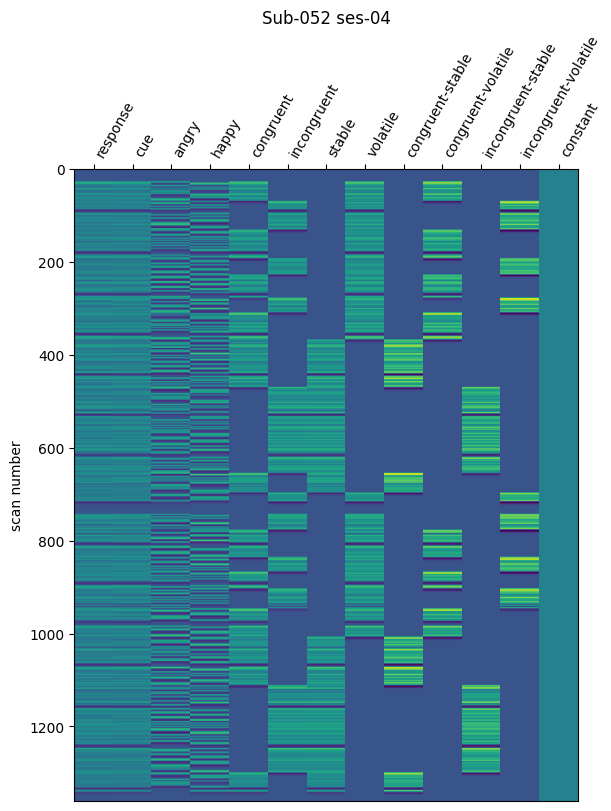

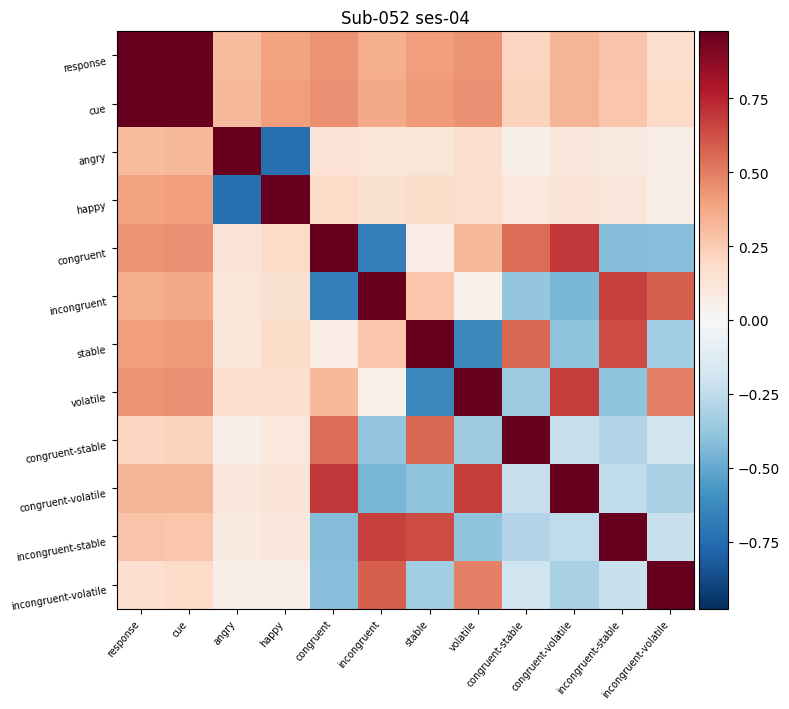

Creating event file for subject 53 and session 2
Creating event file for subject 53 and session 2
              trial_type        onset  duration
0                  happy    38.495073       1.7
1                    cue    38.495073       1.7
2               response    39.496625       0.2
3            incongruent    38.495073       1.7
4               volatile    38.495073       1.7
...                  ...          ...       ...
2635                 cue  2001.283069       1.7
2636            response  2001.997692       0.2
2637         incongruent  2001.283069       1.7
2638              stable  2001.283069       1.7
2639  incongruent-stable  2001.283069       1.7

[2640 rows x 3 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:83: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:93: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


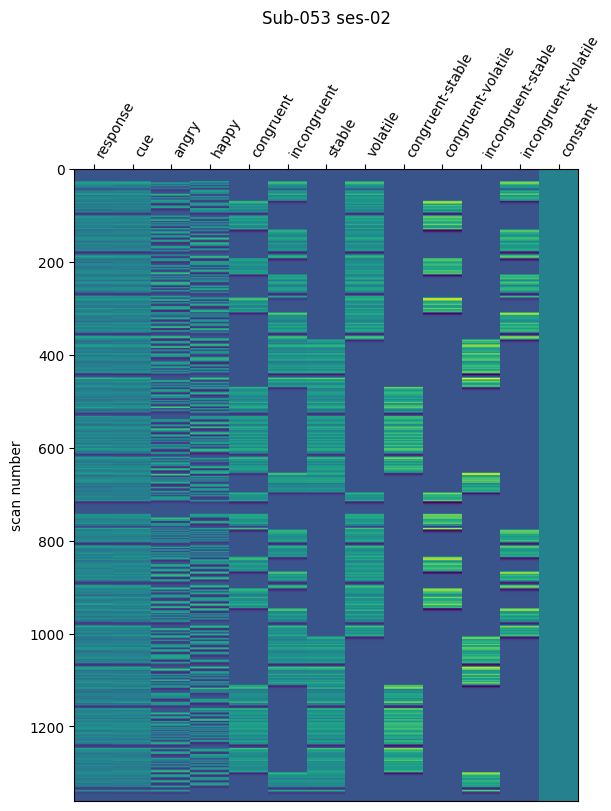

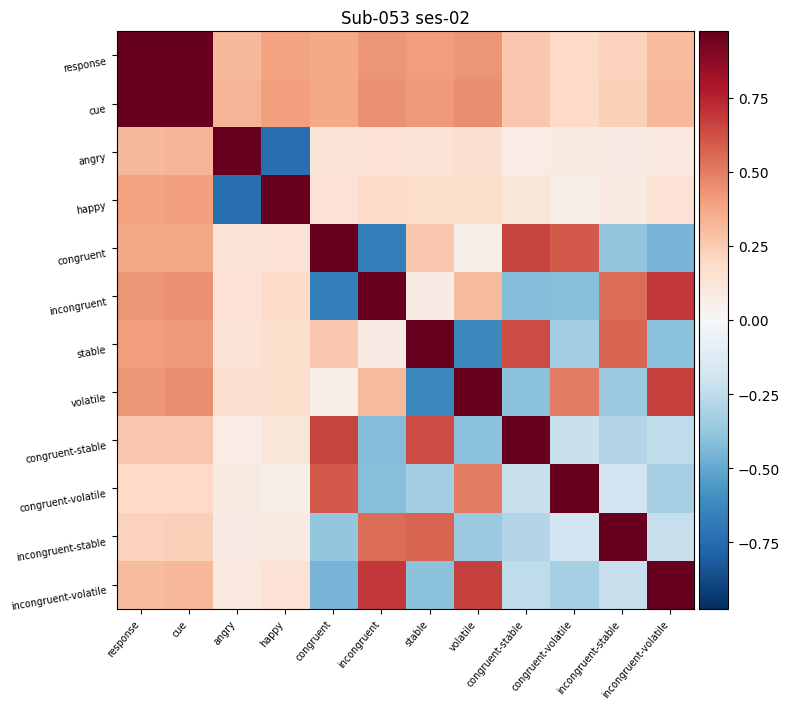

Creating event file for subject 53 and session 3
Creating event file for subject 53 and session 3
                trial_type        onset  duration
0                    angry    38.419943       1.7
1                      cue    38.419943       1.7
2                 response    39.228803       0.2
3              incongruent    38.419943       1.7
4                 volatile    38.419943       1.7
...                    ...          ...       ...
2641                   cue  2001.244060       1.7
2642              response  2001.961630       0.2
2643           incongruent  2001.244060       1.7
2644              volatile  2001.244060       1.7
2645  incongruent-volatile  2001.244060       1.7

[2646 rows x 3 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:83: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:93: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


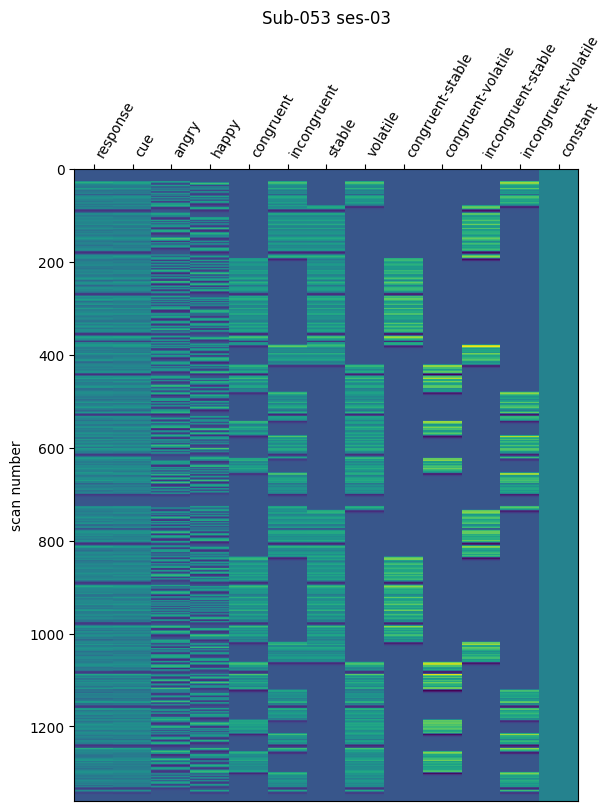

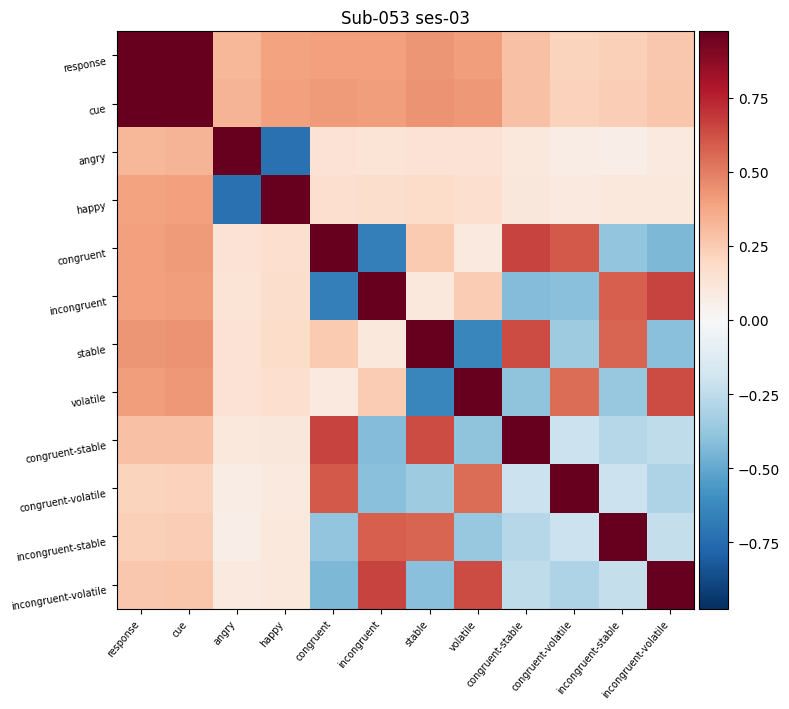

Creating event file for subject 53 and session 4
Creating event file for subject 53 and session 4
            trial_type        onset  duration
0                happy    38.430319       1.7
1                  cue    38.430319       1.7
2             response    39.177258       0.2
3            congruent    38.430319       1.7
4             volatile    38.430319       1.7
...                ...          ...       ...
2599               cue  2000.996065       1.7
2600          response  2001.740393       0.2
2601         congruent  2000.996065       1.7
2602            stable  2000.996065       1.7
2603  congruent-stable  2000.996065       1.7

[2604 rows x 3 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:83: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:93: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


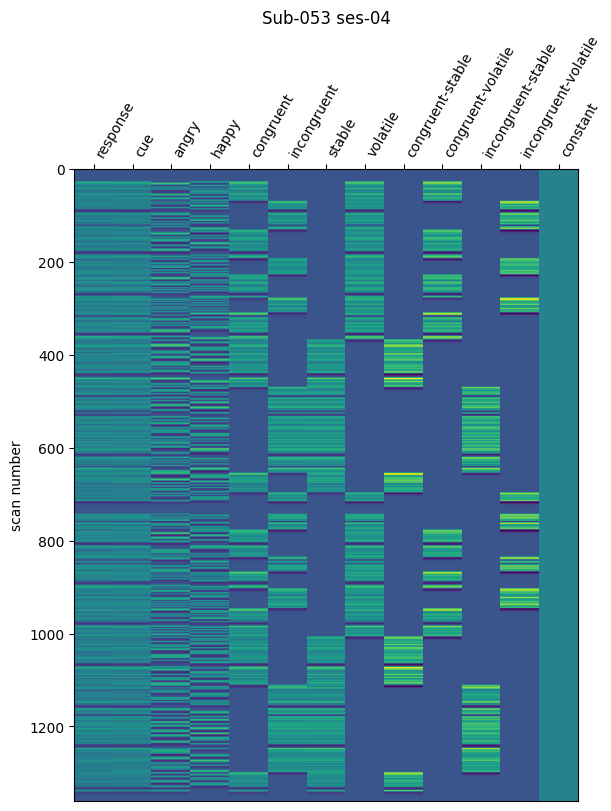

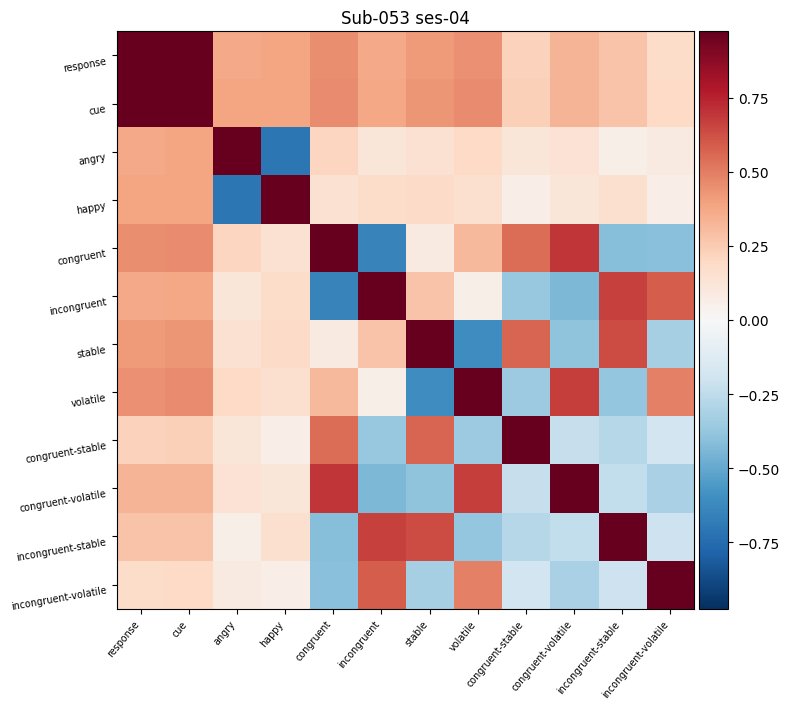

Creating event file for subject 54 and session 2
Creating event file for subject 54 and session 2
              trial_type        onset  duration
0                  happy    38.528642       1.7
1                    cue    38.528642       1.7
2               response    39.107215       0.2
3            incongruent    38.528642       1.7
4               volatile    38.528642       1.7
...                  ...          ...       ...
2635                 cue  2001.886597       1.7
2636            response  2002.454007       0.2
2637         incongruent  2001.886597       1.7
2638              stable  2001.886597       1.7
2639  incongruent-stable  2001.886597       1.7

[2640 rows x 3 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:83: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:93: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


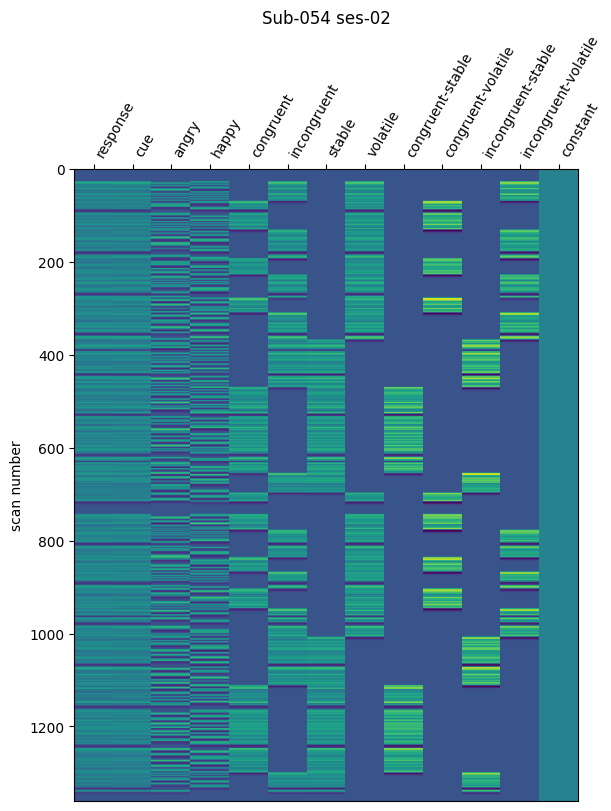

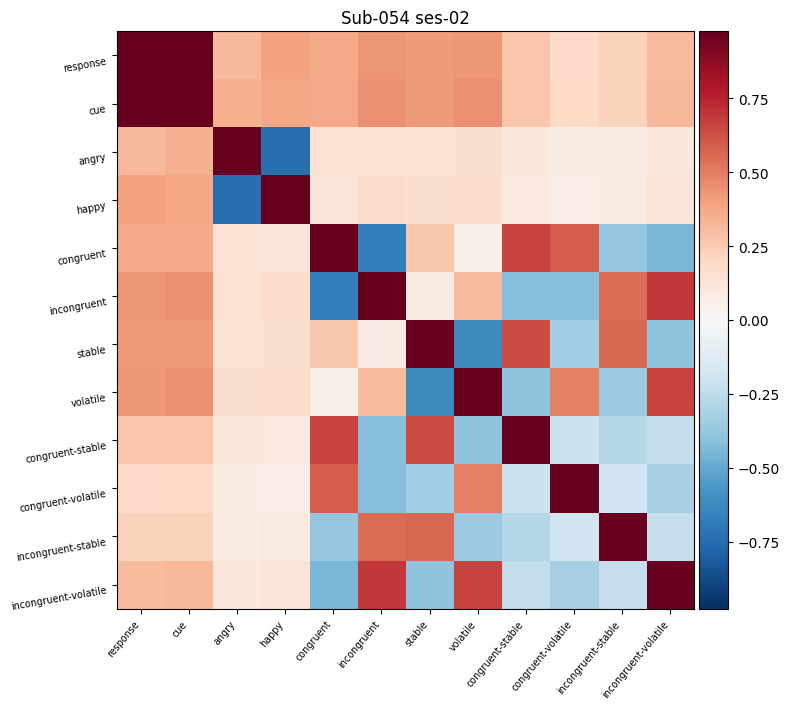

Creating event file for subject 54 and session 3
fMRIprep has not yet been run for subject 54 and session 3
Creating event file for subject 54 and session 4
fMRIprep has not yet been run for subject 54 and session 4
Creating event file for subject 55 and session 2
Creating event file for subject 55 and session 2
              trial_type        onset  duration
0                  happy    42.127190       1.7
1                    cue    42.127190       1.7
2               response    42.615292       0.2
3            incongruent    42.127190       1.7
4               volatile    42.127190       1.7
...                  ...          ...       ...
2599                 cue  2000.419177       1.7
2600            response  2000.870326       0.2
2601         incongruent  2000.419177       1.7
2602              stable  2000.419177       1.7
2603  incongruent-stable  2000.419177       1.7

[2604 rows x 3 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:83: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6182/4114252507.py:93: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


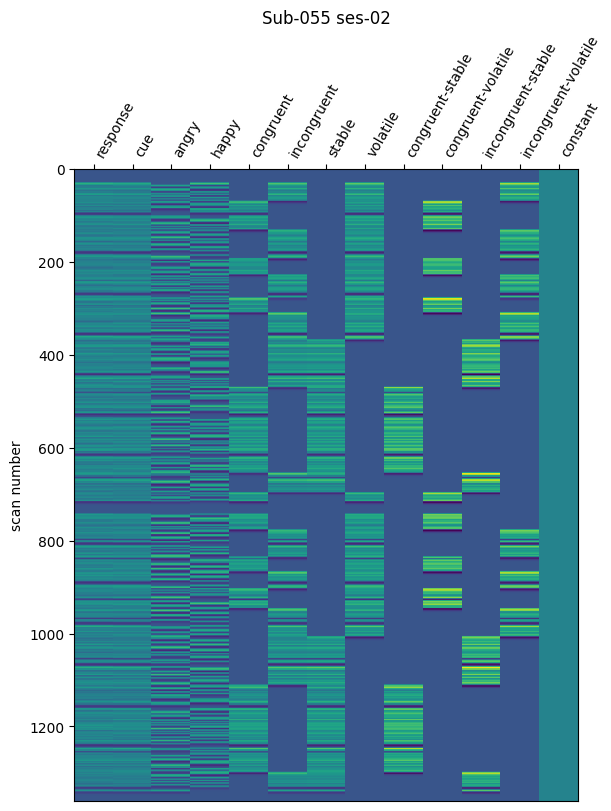

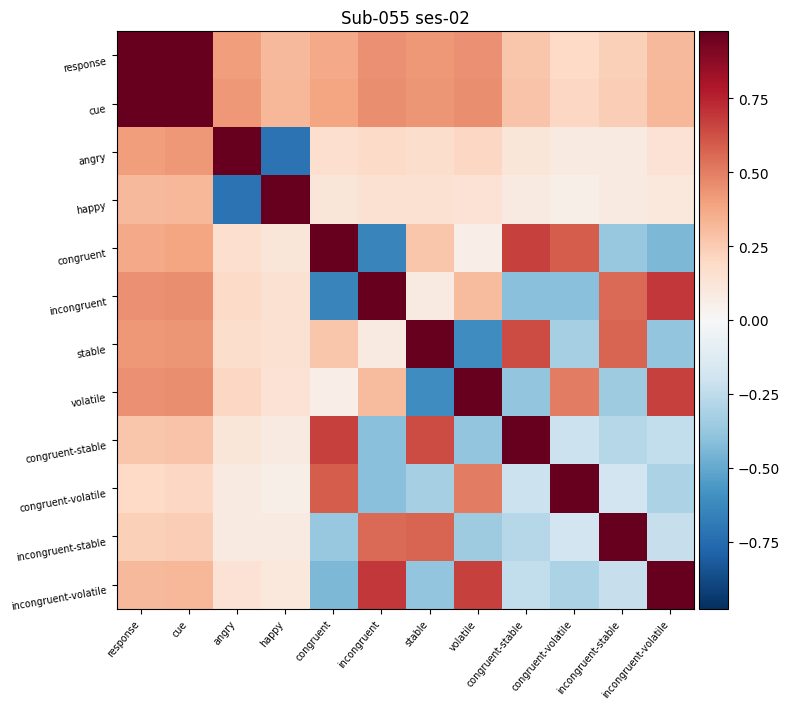

Creating event file for subject 55 and session 3
fMRIprep has not yet been run for subject 55 and session 3
Creating event file for subject 55 and session 4
fMRIprep has not yet been run for subject 55 and session 4
Creating event file for subject 57 and session 2
fMRIprep has not yet been run for subject 57 and session 2
Creating event file for subject 57 and session 3
fMRIprep has not yet been run for subject 57 and session 3
Creating event file for subject 57 and session 4
fMRIprep has not yet been run for subject 57 and session 4


In [5]:
for subject_id in unique_subject_ids:
    for session in unique_sessions:
        # Set subject raw folder for later use:
        project_folder = '/Volumes/project/3025011.02'
        subject_raw_folder = f'{project_folder}/raw/sub-{subject_id:03}/ses-mri{session:02}'
        subject_func_folder = f'{project_folder}/bids/sub-{subject_id:03}/ses-mri{session:02}/func'
        fsl_folder = f'{project_folder}/bids/derivatives/fsl/sub-{subject_id:03}/ses-mri{session:02}/func'
        confounds_file = f'{project_folder}/bids/derivatives/fmriprep/sub-{subject_id:03}/ses-mri{session:02}/func/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_desc-confounds_timeseries.tsv'
        os.makedirs(fsl_folder, exist_ok=True)

        # If participant does not have subject data yet
        if not os.path.exists(confounds_file):
            print(f'fMRIprep has not yet been run for subject {subject_id} and session {session}')
            continue
        else:
            print(f'Creating event file for subject {subject_id} and session {session}')

        dataframe = combined_dataframe[combined_dataframe['subject_id'] == f'sub-{subject_id:03}']
        dataframe = dataframe[dataframe['session'] == f'session-{session:02}']

        # Columns for sanity checks
        dataframe['contains_response'] = np.where(dataframe['response'].notna(), 'response', '')
        dataframe['contains_cue'] = np.where(dataframe['valence'].notna(), 'cue', '')

        # Determine when the scan for the first volume starts
        trigger_signals = find_trigger_file(f'trigger_signals_sub-{subject_id:03}_session-{session:02}*.csv', f'{subject_raw_folder}/beh')
        first_volume_start = trigger_signals.loc[trigger_signals['trigger'] == 1, 'trigger_time'].item()
        # Note down when each trial and each response starts
        dataframe['emotional_cue_time'] = dataframe['emotional_cue_time'] - first_volume_start
        dataframe['response_time'] = dataframe['response_time'] - first_volume_start
        #print(dataframe[['emotional_cue_time', 'response_time']])

        # Combine variables
        dataframe['congruency-volatility'] = dataframe['congruency'] + '-' + dataframe['volatility']
        dataframe['onset'] = dataframe['emotional_cue_time']
        # Create a boxcar
        dataframe['duration'] = boxcar_duration
        #print(dataframe[['valence','congruency','volatility','congruency-volatility','duration']])

        # Restructure into a time-series
        restructured_rows = []
        for _, row in dataframe.iterrows():
            restructured_rows.append({'trial_type': row['valence'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['contains_cue'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['contains_response'], 'onset': row['response_time'], 'duration': 0.2}) # This is obviously a very rough estimate, adjust before final analysis
            restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['volatility'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['congruency-volatility'], 'onset': row['onset'], 'duration': row['duration']})

        # Convert to dataframe
        data_design_matrix = pd.DataFrame(restructured_rows)
        #print(data_design_matrix)

        # Now create the design matrix and save it
        events = pd.DataFrame(
            {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
        )
        print(events)
        events.to_csv(os.path.join(f'{subject_func_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_events.tsv'), sep='\t')

        # Scans timing
        # This method takes the actual triggers instead of assuming that the TR = 1.5 and that no scans are missed
        n_triggers = len(trigger_signals)
        trigger_timepoints = trigger_signals['trigger_time'] - first_volume_start
        trigger_timepoints = trigger_timepoints.tolist()

        # Repetition time
        tr = 1.5
        # Look up number of volumes (since it's multi-echo, we need to divide by 3)
        raw_bold_folder = Path(f'{subject_raw_folder}/006-TaskAARL')
        # Count .IMA files to check if it matches the number of triggers
        ima_files = list(raw_bold_folder.glob('*.IMA'))
        n_volumes = int(len(ima_files) / 3)
        volume_timepoints = np.arange(0, n_volumes) * tr

        if n_triggers != n_volumes:
            raise ValueError(
                f'Number of triggers ({n_triggers}) does not match the number of IMA files ({n_volumes})'
            )

        # fit the hemodynamic response function to the event file
        design_matrix = make_first_level_design_matrix(
            np.array(trigger_timepoints),
            data_design_matrix
        )

        # Explicitly reorder columns
        design_matrix = design_matrix[['response', 'cue', 'angry', 'happy', 'congruent', 'incongruent', 'stable', 'volatile', 'congruent-stable', 'congruent-volatile', 'incongruent-stable', 'incongruent-volatile', 'constant']]

        # Plot said matrix and save it
        fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)
        plot_design_matrix(design_matrix, ax=ax)
        ax.set_title(f'Sub-{subject_id:03} ses-{session:02}')
        plt.savefig(os.path.join(output_dir, f'design_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))

        # Now also plot the correlation matrix and save it
        fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
        plot_design_matrix_correlation(design_matrix, axes=ax)
        ax.set_title(f'Sub-{subject_id:03} ses-{session:02}')
        plt.savefig(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))
        plt.show()
        # And save a CSV version of it
        correlation_matrix = design_matrix.corr()
        correlation_matrix.round(3).to_csv(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.csv'), sep=';')

        # Because FSL can only accept an event file with one variable in there, we will now split them up
        for trials_type in events['trial_type'].unique():
            trial_specific_events = events[events['trial_type'] == trials_type]
            trial_specific_events = trial_specific_events[['onset', 'duration']].copy()
            trial_specific_events['weight'] = 1.0
            trial_specific_events.to_csv(f'{fsl_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_regressor_{trials_type}.txt', sep='\t', index=False, header=False)

        # Now select the confounds you want to copy into the FEAT analysis
        confounds = pd.read_csv(confounds_file, sep='\t') # Location of fMRIprep results

        confounds_for_feat = confounds[['trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'framewise_displacement', 't_comp_cor_00','t_comp_cor_01','t_comp_cor_02','t_comp_cor_03', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03']]
        confounds_for_feat = confounds_for_feat.fillna(0)
        confounds_for_feat.to_csv(f'{fsl_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_confounds_for_feat.txt', sep='\t', index=False, header=False)